# A Deep Dive into Bayesian Model Comparison with BayesFlow

_Author: Jerry M. Huang_

In this notebook, we take a deep dive into Bayesian model comparison by demonstrating the `ModelComparisonWorkflow` in BayesFlow. We will demonstrate two capabilities that the workflow has to offer: Bayes factor (BF) and posterior model probability (PMP) estimation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from numba import njit

import bayesflow as bf

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
rng = np.random.default_rng(seed=2026)

## Categorical Scoring Rules

At the heart of any model comparison workflow is a **scoring rule** — a loss function that determines how the network learns to distinguish models. The scoring rule shapes the training dynamics, while BayesFlow derives posterior model probabilities and Bayes factors from the corresponding network outputs.

### What the scores learn

All categorical scoring rules in `ModelComparisonWorkflow` use length-$M$ estimation heads for the $M$ candidate models. The returned evidence quantity is called `log_odds`, not because these values are log posterior odds. They equal log Bayes factors only when the model prior is uniform.

Let $\ell(\mathbf{x}) = (\ell_1(\mathbf{x}), \ldots, \ell_M(\mathbf{x}))$ denote the model logits learned for a dataset $\mathbf{x}$. Note, that statisticians do not like to call these "logits", so we side withe ML community on this terminological debate. Posterior model probabilities (PMPs) are obtained by softmax-normalizing these logits:

$$
\hat p_k(\mathbf{x}) = P(\mathcal{M}_k \mid \mathbf{x}) = \frac{\exp(\ell_k(\mathbf{x}))}{\sum_{j=1}^{M} \exp(\ell_j(\mathbf{x}))}.
$$

Log odds are then reported relative to a reference model, usually $\mathcal{M}_0$:

$$
\widehat{\log O}_{k,0}(\mathbf{x}) = \log \frac{\hat p_k(\mathbf{x})}{\hat p_0(\mathbf{x})} = \ell_k(\mathbf{x}) - \ell_0(\mathbf{x}), \qquad k = 0, \ldots, M-1,
$$

so the reference entry is zero by construction. If the model prior probabilities $\pi_k = P(\mathcal{M}_k)$ are known, posterior odds decompose into prior odds and Bayes factors:

$$
\log \frac{P(\mathcal{M}_k \mid \mathbf{x})}{P(\mathcal{M}_0 \mid \mathbf{x})} = \log \mathrm{BF}_{k,0}(\mathbf{x}) + \log \frac{\pi_k}{\pi_0}.
$$

BayesFlow therefore derives prior-adjusted log Bayes factors as

$$
\widehat{\log \mathrm{BF}}_{k,0}(\mathbf{x}) = \widehat{\log O}_{k,0}(\mathbf{x}) - \log \frac{\pi_k}{\pi_0}.
$$

With uniform priors, the prior-odds correction vanishes, so log odds and log Bayes factors coincide. With non-uniform priors, they do not. Prior model weights come from the simulator when available; otherwise BayesFlow assumes equal model priors.

The scoring rules mainly differ in how they train this same length-$M$ object. Probability-space rules such as `BrierScore` and `PolynomialScore` attach a softmax link, which maps the head pre-activation logits to probabilities before the loss sees them. `LogisticScore` and `ExponentialScore` use the default identity link, so the loss acts directly on raw, unnormalized logits/log odds. `CrossEntropyScore` can be used with either input space. In other words, the rules change the geometry and numerical behavior of optimization; they do not change the fact that `estimate()` exposes the same derived quantities.

## Simple Example: Normal-Normal Model

To illustrate, we start with the simplest possible setting. We will compare four Gaussian models that differ only in their prior on the mean. The observation model is identical across all four, and the conjugate structure gives **closed-form marginal likelihoods**, so ground-truth log Bayes factors are available for every test dataset.

We will train the network with a Bayes factor scoring rule, then immediately check how well it recovers the analytic truth using `bayes_factor_recovery`.

### Model specification

The four models are intentionally minimal: they share the same observation model:

\begin{equation}
x_i \mid \mu \sim \mathcal{N}(\mu, 1) 
\end{equation}

and differ only in the prior placed on $\mu$ which varies its mean and width.

| Model | Prior |
|-------|-------|
| $M_1$ (ref.) | $\mu \sim \mathcal{N}(0,\ 1)$ — wide, centered |
| $M_2$ | $\mu \sim \mathcal{N}(0,\ 0.25)$ — narrow, centered |
| $M_3$ | $\mu \sim \mathcal{N}(1,\ 1)$ — wide, shifted |
| $M_4$ | $\mu \sim \mathcal{N}(1,\ 0.25)$ — narrow, shifted |

In [3]:
N_OBS = 50

# (mu0, tau) for each model's prior mu ~ N(mu0, tau^2)
PRIOR_PARAMS = [
    (0.0, 1.0),   # M1 (ref): wide, centered
    (0.0, 0.5),   # M2: narrow, centered
    (1.0, 1.0),   # M3: wide, shifted
    (1.0, 0.5)    # M4: narrow, shifted
]

In [4]:
def prior_1():
    return dict(mu=rng.normal(loc=0.0, scale=1.0))

def prior_2():
    return dict(mu=rng.normal(loc=0.0, scale=0.5))

def prior_3():
    return dict(mu=rng.normal(loc=1.0, scale=1.0))

def prior_4():
    return dict(mu=rng.normal(loc=1.0, scale=0.5))

def likelihood(mu, **kwargs):
    x = np.random.normal(loc=mu, scale=1.0, size=(N_OBS, 1)).astype(np.float32)
    return dict(x=x)

# Bundling everything together
simulators = [
    bf.make_simulator([prior_1, likelihood]),
    bf.make_simulator([prior_2, likelihood]),
    bf.make_simulator([prior_3, likelihood]),
    bf.make_simulator([prior_4, likelihood])
]

Because $\sigma=1$ is fixed and each prior is conjugate Gaussian, integrating out $\mu$ gives a closed-form marginal likelihood:

$$
\log p(\mathbf{x} \mid M_k) =
  -\frac{n}{2}\log(2\pi)
  - \frac{1}{2}\log\!\left(1 + n\tau_k^2\right)
  - \frac{1}{2}\!\left[
      \sum_i x_i^2
      + \frac{\mu_{0,k}^2}{\tau_k^2}
      - \frac{\displaystyle\left(n\bar{x} + \frac{\mu_{0,k}}{\tau_k^2}\right)^2}{\displaystyle n + \frac{1}{\tau_k^2}}
    \right]
$$

Ground-truth log Bayes factors $\log \mathrm{BF}_{k,1} = \log p(\mathbf{x}\mid M_k) - \log p(\mathbf{x}\mid M_1)$ are computed analytically per dataset and used to validate the network via `bayes_factor_recovery`.

In [5]:
def log_marginal_likelihood(x, mu0, tau):
    """Analytic log marginal likelihood: x_i | mu ~ N(mu, 1), mu ~ N(mu0, tau^2)."""
    n = len(x)
    x_bar = np.mean(x)
    ss = np.sum(x ** 2)
    prec_prior = 1.0 / tau ** 2
    B = n * x_bar + mu0 * prec_prior
    A = n + prec_prior
    return (
        -n / 2 * np.log(2 * np.pi)
        - 0.5 * np.log(1.0 + n * tau ** 2)
        - 0.5 * (ss + mu0 ** 2 * prec_prior - B ** 2 / A)
    )


def compute_true_log_bfs(test_data, reference=0):
    """Compute analytic log BFs of shape (B, num_models-1) from simulated test data."""
    x_batch = test_data["x"]
    B = x_batch.shape[0]
    mu0_ref, tau_ref = PRIOR_PARAMS[reference]
    competing = [k for k in range(len(PRIOR_PARAMS)) if k != reference]
    log_bfs = np.zeros((B, len(competing)))
    for i, k in enumerate(competing):
        mu0_k, tau_k = PRIOR_PARAMS[k]
        for b in range(B):
            x = x_batch[b, :, 0].astype(np.float64)
            log_bfs[b, i] = (
                log_marginal_likelihood(x, mu0_k, tau_k)
                - log_marginal_likelihood(x, mu0_ref, tau_ref)
            )
    return log_bfs

### Workflow setup

The only addition compared to `BasicWorkflow` is the `scoring_rules` argument. Here we use the exponential score. Swapping in `ExponentialScore(leaky=2.0)` or any other rule requires no other changes to the workflow.

There is no need to pass `inference_variables`. Within `ModelComparisonWorkflow`, they will automatically be named `model_indices` if no custom `Adapter` is provided.

In [11]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="x",
    summary_network=bf.networks.SetTransformer(),
    scoring_rules="exponential",
    initial_learning_rate=1e-3
)

Training uses the same interface as any other BayesFlow workflow. Below, we demonstrate online training, as our models are trivial to simulate.

In [ ]:
history = workflow.fit_online(epochs=50, num_batches_per_epoch=50, batch_size=128)

We can inspect how our `ModelComparisonWorkflow` performs by looking at the default diagnostics:

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 0.04 seconds.


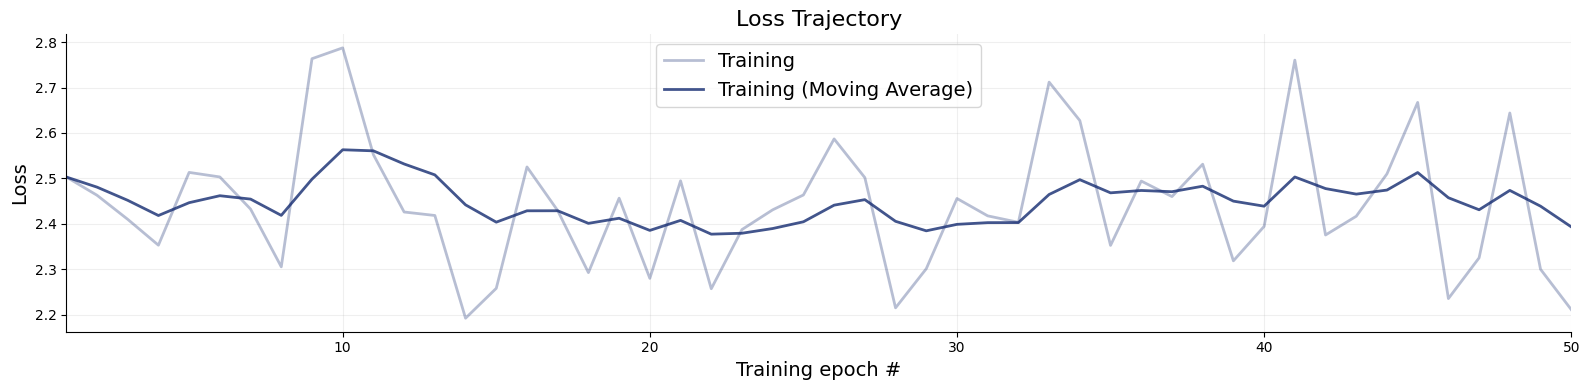

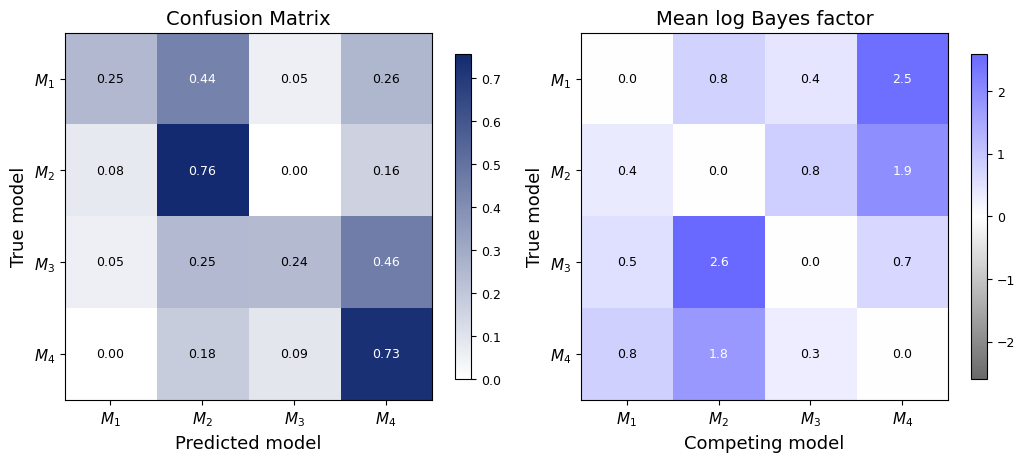

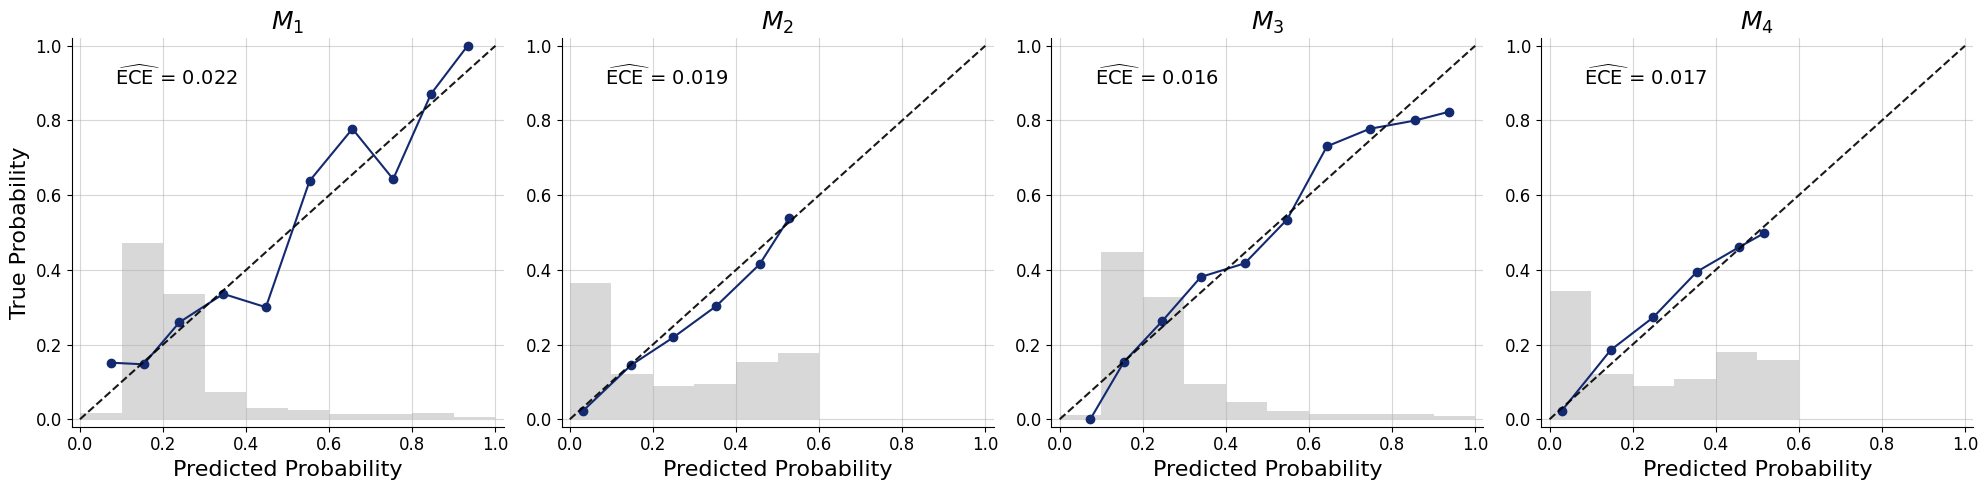

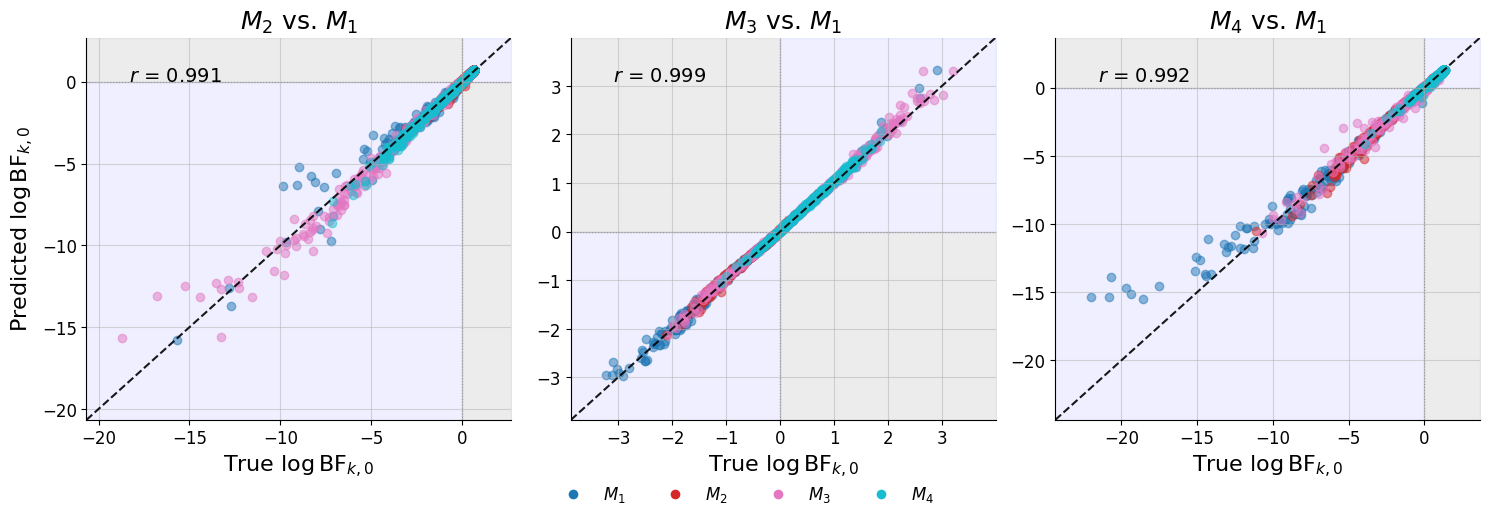

In [13]:
figures = workflow.plot_default_diagnostics(test_data=2000, true_log_bfs_fn=compute_true_log_bfs)

Because we supplied `true_log_bfs_fn`, the workflow produces **four** diagnostic plots for BF rules:

- **Loss trajectory** — the training loss of the Bayes factor scoring rule (here `ExponentialScore`) across epochs, shown both as the raw per-epoch value and as an exponential moving average. Because the exponential rule targets a real-valued likelihood ratio, the loss is inherently noisy from epoch to epoch and a single batch can be dominated by a few datasets with extreme Bayes factors. In addition, our models are simple enough for the loss trajectory to flatten quickly.

- **Calibration curves** — reliability diagrams that assess whether the PMPs derived from the network's log BFs are trustworthy as probability estimates. Each panel bins the predicted PMP $\hat{P}(\mathcal{M}_k \mid \mathbf{x})$ on the x-axis and shows the empirical fraction of datasets in that bin that truly came from $\mathcal{M}_k$ on the y-axis; the ECE is the weighted mean absolute deviation from the diagonal. A well-calibrated network tracks the diagonal closely. Curves bowing above indicate underconfidence, curves bowing below indicate overconfidence — and either can occur independently of how sharp the BF recovery looks.

- **Pairwise log Bayes factors** — heatmap of the mean $\log \mathrm{BF}_{m,j}$ stratified by true model. Each row $m$ shows the average predicted log BF favoring model $m$ over each competitor $j$, averaged over all test datasets truly generated from $\mathcal{M}_m$. Diagonal entries are zero by construction ($\mathrm{BF}_{m,m} = 1$). If the models are easily distinguishable, a well-trained network produces large positive off-diagonal entries in every row, confirming that the predicted evidence consistently favors the correct model over alternatives.

- **Bayes factor recovery** — scatter plot of predicted $\log \mathrm{BF}_{k,0}$ against the analytic truth, colored by the true generating model. Points should cluster tightly around the diagonal. The background is shaded into quadrants by the **sign** of the true and predicted log BF, because the sign is what determines the model-selection decision: a positive $\log \mathrm{BF}$ favors the competing model, a negative one favors the reference. The green quadrants (lower-left and upper-right) are therefore the **agreement** regions, where the true and predicted Bayes factors point to the same model — i.e. the decision is correct — while the red quadrants (upper-left and lower-right) are **disagreement** regions, where the network would select the wrong model. This shading makes decision errors visible at a glance and separates them from mere magnitude errors: a point can sit far from the diagonal yet still land in a green quadrant (right decision, wrong strength), or hug the axes yet cross into red (a sign flip near $\log \mathrm{BF} = 0$, where the evidence is weak anyway). The Pearson correlation $r$ annotated on each panel quantifies overall recovery quality.

### What do the diagnostics tell us here?

- The network recovers the analytic Bayes factors well: $r \approx 0.97$–$0.99$, with points hugging the diagonal inside the green agreement quadrants and the only strays near $\log \mathrm{BF} = 0$, where a sign flip barely matters. The calibration curves also indicate that the estimated posterior model probabilities are well-calibrated (ECE $< 0.02$).


- The **confusion matrix** shows, for each true generating model, how often the network's top prediction (argmax of the PMPs) agrees with it. Rows are the true model, columns are the predicted model, and diagonal mass indicates correct classification; off-diagonal entries tend to accumulate between structurally similar model pairs.

- The **log Bayes factor matrix** further implies that separations are largest between models that differ in **both** prior location and width ($M_1$ vs. $M_4$, $\approx 2.4$ log units) and smallest between models that differ in only a **single** aspect — $M_1$ vs. $M_2$ (same mean, different width, $\approx 0.6$) or $M_1$ vs. $M_3$ (same width, shifted mean, $\approx 0.5$). Detecting a single changed feature from $n = 50$ observations yields only modest evidence, and the network reproduces this faithfully.



## Real-World Example: GARCH Volatility Models

The normal-normal example gave us a clean sandbox — conjugate structure, closed-form ground truth, fully controlled discrimination difficulty. But the central premise of amortized inference is that the Bayesian workflow can also be applied to much more complex models, even with intractable likelihoods.

We now discriminate between four models from the **Generalized Autoregressive Conditional Heteroscedasticity (GARCH) model family**, the workhorse of volatility modeling in computational finance. All four share the same return-generating mechanism but differ in how they model the evolution of conditional variance: one captures only short-memory shocks (ARCH), one adds persistent volatility clustering (GARCH), one introduces an asymmetric leverage effect (GJR-GARCH), and one allows for heavy-tailed innovations (GARCH-t). These are genuinely hard to tell apart from a finite return series — they are nested or near-nested, and the distinguishing features manifest most clearly under extreme market conditions.

Here we estimate the PMPs directly via a PMP scoring rule. We could equally have estimated Bayes factors via a BF scoring rule: because BayesFlow is fully **simulation-based**, the network never evaluates a likelihood, so *both* families of scoring rules are available whether or not the likelihood — or the marginal likelihood — is analytically tractable.

We nonetheless prefer PMPs here, for three reasons. First, they are exactly the quantity we want — a probability for each of the four models, ready for ranking or selection. Second, their outputs are bounded by the softmax function, making them easier and more stable to learn than a real-valued, potentially large log Bayes factor. This is beneficial because the models we are comparing are near-nested, and the return series is long, where marginal-likelihood ratios can grow extreme. And finally, PMPs can be validated with no ground truth at all, through the confusion matrix and calibration curves. Choosing BFs would forfeit this last advantage: since GARCH marginal likelihoods have no closed form, there would be no ground-truth Bayes factors to feed `bayes_factor_recovery` — though the calibration and pairwise-BF diagnostics would remain available either way.

### Model specification

The four models form a progression of increasing complexity, each adding one structural feature: volatility persistence, an asymmetric leverage effect, and heavy-tailed innovations.

| Model | Key feature |
|-------|-------------|
| ARCH(1) | Short-memory ARCH: volatility shocks decay in one step |
| GARCH(1,1) | Persistent volatility clustering, Gaussian innovations |
| GJR-GARCH(1,1) | Leverage effect: negative shocks inflate variance more |
| GARCH-t | GARCH(1,1) with Student-t innovations; heavier tails |

Here, we unify them into a single simulator that contains all four models as special cases.

In [23]:
@njit
def simulate_garch(omega, alpha, mu, beta, gamma, nu, T, burn_in):
    """JIT-compiled GARCH recursion. nu=inf selects Gaussian innovations."""
    T_total = T + burn_in
    returns = np.empty(T_total)
    eps = 0.0
    sigma2 = omega / max(1.0 - alpha - gamma * 0.5 - beta, 1e-6)
    use_gaussian = np.isinf(nu)

    for t in range(T_total):
        I_neg = 1.0 if eps < 0.0 else 0.0
        sigma2 = omega + (alpha + gamma * I_neg) * eps * eps + beta * sigma2
        if sigma2 < 1e-10:
            sigma2 = 1e-10
        elif sigma2 > 1.0:
            sigma2 = 1.0
        if use_gaussian:
            z = np.random.randn()
        else:
            z = np.random.standard_t(nu) * np.sqrt((nu - 2.0) / nu)
        eps = np.sqrt(sigma2) * z
        returns[t] = mu + eps

    out = returns[burn_in:].copy()
    for i in range(len(out)):
        if out[i] < -1.0:
            out[i] = -1.0
        elif out[i] > 1.0:
            out[i] = 1.0
    return out


def garch_model(omega, alpha, mu, beta=0.0, gamma=0.0, nu=None, T=300, burn_in=50, **kwargs):
    """Shared GARCH model for all variants.

    beta=0, gamma=0, nu=None/inf  →  ARCH(1)
    gamma=0, nu=None/inf          →  GARCH(1,1)
    nu=None/inf                   →  GJR-GARCH(1,1)
    nu provided and finite        →  GARCH-t (Student-t innovations scaled to unit variance)
    """
    nu_val = np.inf if (nu is None or np.isinf(nu)) else nu
    out = simulate_garch(omega, alpha, mu, beta, gamma, nu_val, T, burn_in)
    return {"returns": out[:, np.newaxis].astype(np.float32)}


# Warm up both JIT branches (Gaussian and Student-t) to pay compile cost once.
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, np.inf, 60, 10)
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, 5.0,    60, 10)
print("JIT warmup complete.")

JIT warmup complete.


Each model is defined by a prior function that draws parameters, with all four sharing a single likelihood that runs the GARCH recursion. `bf.make_simulator` chains them so the prior's output dict is forwarded automatically as keyword arguments to the likelihood. The unified likelihood covers all four variants via its optional parameters:

| Model | `beta` | `gamma` | `nu` |
|-------|--------|---------|------|
| ARCH(1) | 0 (default) | 0 (default) | None (default) |
| GARCH(1,1) | sampled | 0 (default) | None (default) |
| GJR-GARCH(1,1) | sampled | sampled | None (default) |
| GARCH-t | sampled | 0 (default) | sampled |

In [15]:
def arch_prior():
    return dict(
        omega=rng.uniform(5e-5, 2e-4),
        alpha=rng.uniform(0.15, 0.45),
        beta =0.0,
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garch_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def gjr_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        gamma=rng.uniform(0.10, 0.16),
        beta =rng.uniform(0.83, 0.88),
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garcht_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),
        gamma=0.0,
        nu   =rng.uniform(2.5, 4.5),
        mu   =rng.uniform(-5e-4, 5e-4),
    )

In [25]:
arch_simulator = bf.make_simulator([arch_prior, garch_model])
garch_simulator = bf.make_simulator([garch_prior, garch_model])
gjr_simulator = bf.make_simulator([gjr_prior, garch_model])
garcht_simulator = bf.make_simulator([garcht_prior, garch_model])

simulators = [arch_simulator, garch_simulator, gjr_simulator, garcht_simulator]
model_names = ["ARCH", "GARCH", "GJR", "GARCH-t"]

### Prior predictive check

A single draw from each simulator illustrates what the network is up against. At least the first three series look deceptively similar. Yet, as we will see, their statistical fingerprints are distinct enough for a well-trained network to tell them apart reliably.

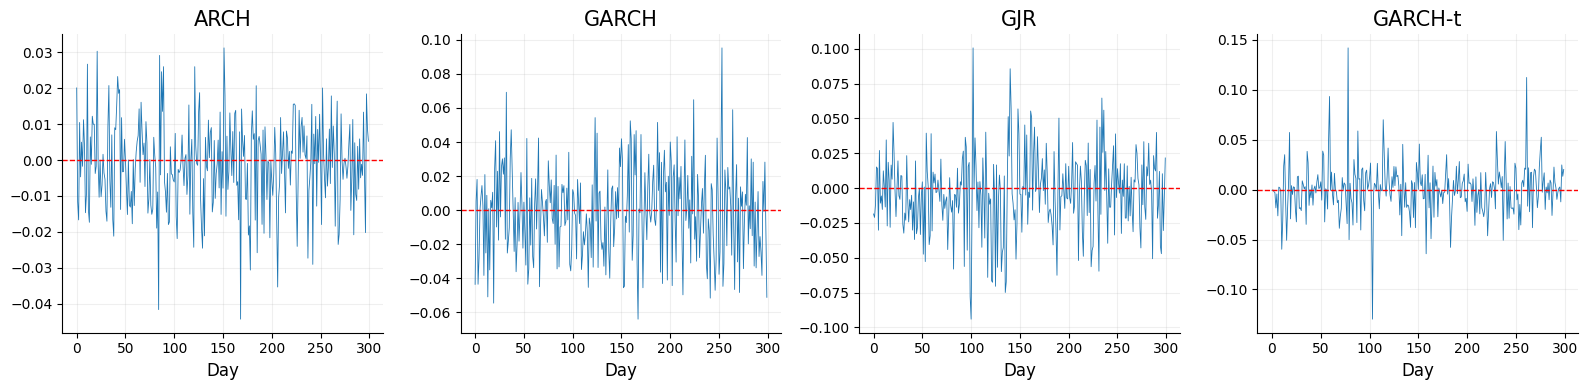

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, sim, name in zip(axes, simulators, model_names):
    path = sim.sample((5,))["returns"][4, :]
    sns.lineplot(path, linewidth=0.6, ax=ax, legend=False, color="purple")
    ax.grid(alpha=0.2)
    ax.set_title(name, fontsize=15)
    ax.set_xlabel("Day", fontsize=12)
    ax.axhline(0, color="red", linewidth=1, linestyle="--")
    sns.despine()
fig.tight_layout()

### Workflow Setup

Next, we define our `ModelComparisonWorkflow` for the GARCH models. As summary network, we choose a `TimeSeriesTransformer`, which is well suited to summarize sequential data. We train with the default `CrossEntropyScore`. Swapping in `BrierScore()` or `PolynomialScore(alpha=3.0)` would require no change to the workflow other than the `scoring_rules` argument.

In [38]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="returns",
    summary_network=bf.networks.TimeSeriesTransformer(),
    scoring_rules="logistic",
    model_names=model_names
)

In [39]:
train_data = workflow.simulate(20_000)
val_data = workflow.simulate(1000)

In [ ]:
history = workflow.fit_offline(train_data, epochs=60, batch_size=128, validation_data=val_data)

### Diagnostics

`plot_default_diagnostics` works for both scoring rule families — it detects the active rule and automatically selects the appropriate plots. Here, with a PMP rule, it produces a loss curve, a confusion matrix, and calibration curves.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 0.11 seconds.


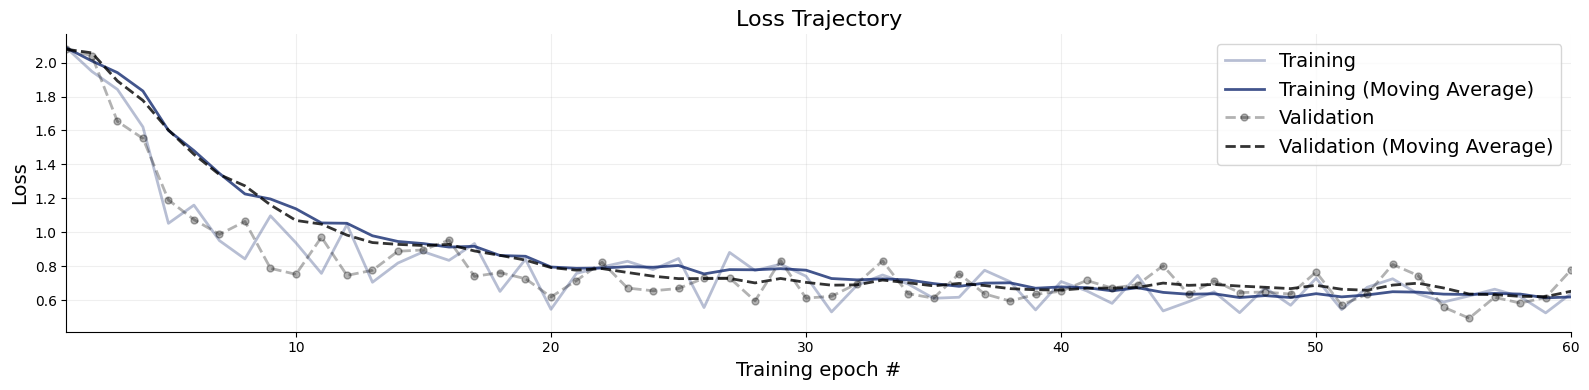

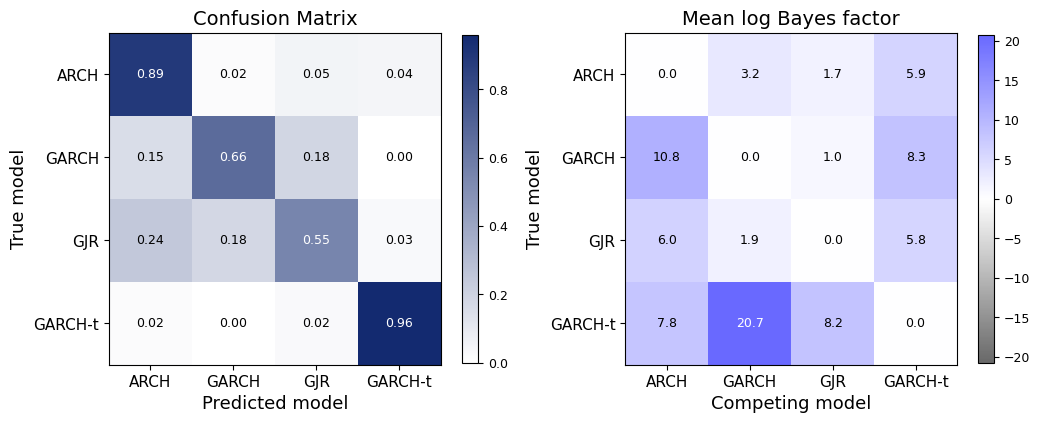

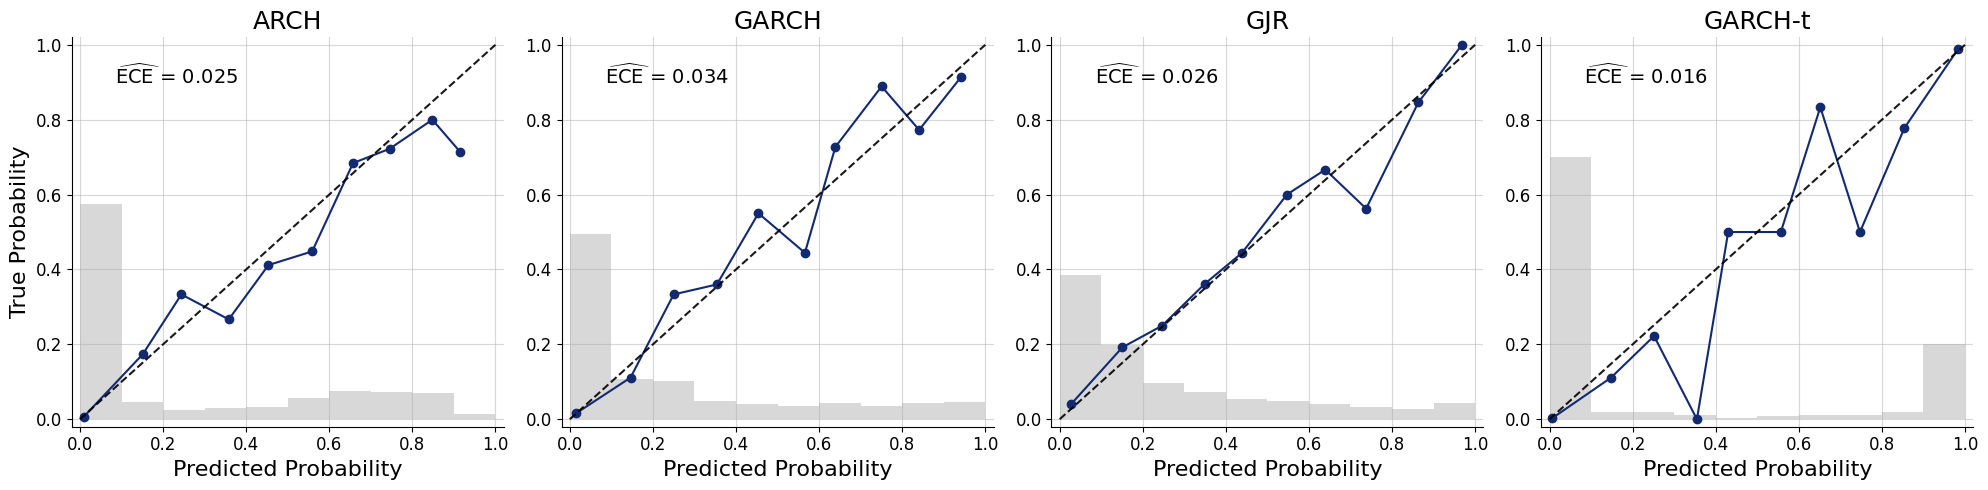

In [41]:
figures = workflow.plot_default_diagnostics(test_data=500)

Let us read the three diagnostics in turn.

- **Loss.** Unlike the noisy exponential loss in the normal-normal example, the cross-entropy loss here descends smoothly, indicating that training has converged and the classifier has learned to extract discriminative structure from the return series.

- **Confusion matrix.** The results largely reflect the structural relationships between the models — though not in the way one might naively guess. **ARCH** and **GARCH-t** are both identified reliably: ARCH stands out because its zero-persistence dynamics produce a qualitatively different volatility profile, and GARCH-t is betrayed by its heavy-tailed innovations ($\nu \in [2.5, 4.5]$), whose occasional extreme returns leave an unmistakable fingerprint. The genuinely difficult pair is not GARCH vs. GARCH-t but **GJR vs. GARCH**: GJR is most often mistaken for plain GARCH. This makes sense — the only thing separating them is the leverage effect, an *asymmetric* response to negative shocks that reveals itself just during large downward moves, which are rare in a 500-step series with these priors. A residual smear of ARCH ↔ GARCH/GJR confusion appears for the same reason in reverse: datasets in which the persistent models happen to show little volatility clustering look ARCH-like.

- **Calibration.** All four reliability curves stay close to the diagonal, with ECEs between $\approx 0.02$ and $0.05$ — so despite the GJR/GARCH confusion, the reported probabilities are honest: when the network says a series is 60% likely to be GJR, it is right about 60% of the time. The largest wobbles sit in the high-probability bins, where confident predictions are common but individual bins hold few datasets, making the empirical frequency noisier. Overall, the network expresses its uncertainty about the leverage effect as graded probabilities rather than overconfident misclassifications.

## Combining Multiple Scoring Rules at Once

Every workflow so far has used a *single* scoring rule. But `ModelComparisonWorkflow` accepts **several at once** — pass a list (or a `{name: rule}` dict) and it attaches one prediction head per rule on top of the shared summary network, trains them jointly, and **pools** their outputs into a single set of estimates (a log opinion pool over the model log-odds).

Why reach for more than one rule? Three reasons:

- **Robustness through ensembling.** Every proper scoring rule is minimized *in expectation* by the true posterior, but on finite data and finite optimization each settles in a slightly different place, with its own bias–variance profile. `CrossEntropyScore` penalizes wrong probabilities logarithmically, `BrierScore` quadratically, `PolynomialScore` with a tunable exponent. Averaging several proper rules cancels part of that idiosyncratic error, much as an ensemble of classifiers beats its individual members.

- **Two target quantities from one network.** Mixing a *PMP* rule with a *Bayes factor* rule yields both quantities simultaneously — bounded, ready-to-rank posterior model probabilities **and** interpretable pairwise log Bayes factors — from a single training run. You no longer have to commit to one representation before training.

- **A richer, self-consistent diagnostic picture.** With both families present, the default diagnostics report *both* the PMP confusion matrix and the pairwise-BF heatmap, so the two views can be cross-checked against each other.

We reuse the GARCH simulators, priors, summary network, and `model_names` from the previous section **unchanged** — the only thing that changes is the `scoring_rules` argument, now a list combining a PMP rule (`CrossEntropyScore`) and a Bayes factor rule (`LogisticScore`).

In [43]:
multi_rule_workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="returns",
    summary_network=bf.networks.TimeSeriesTransformer(),
    scoring_rules=[
        bf.scoring_rules.CrossEntropyScore(),
        bf.scoring_rules.LogisticScore(),
    ],
    model_names=model_names
)

In [ ]:
history = multi_rule_workflow.fit_offline(
    train_data, epochs=60, batch_size=128, validation_data=val_data
)

### Diagnostics with multiple scoring rules

With **both** families active, `plot_default_diagnostics` detects that a PMP rule *and* a Bayes factor rule are present and draws the confusion matrix (from the pooled PMPs) and the pairwise log-Bayes-factor heatmap (from the pooled log-BFs) **side by side in a single figure**, followed by the calibration curves. Every plot runs on the *pooled* estimates, so it reflects the ensemble rather than any single head.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 0.12 seconds.


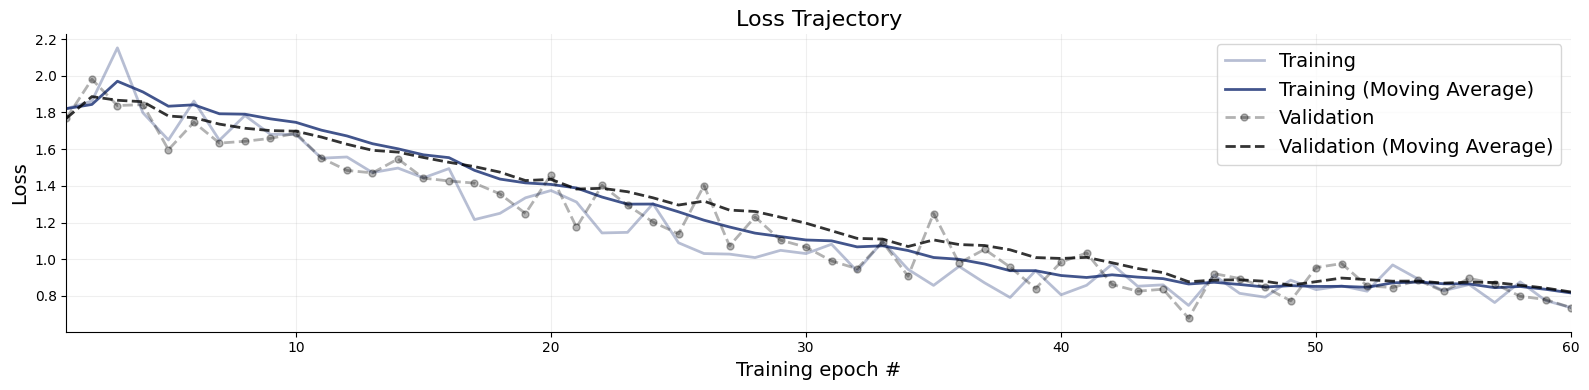

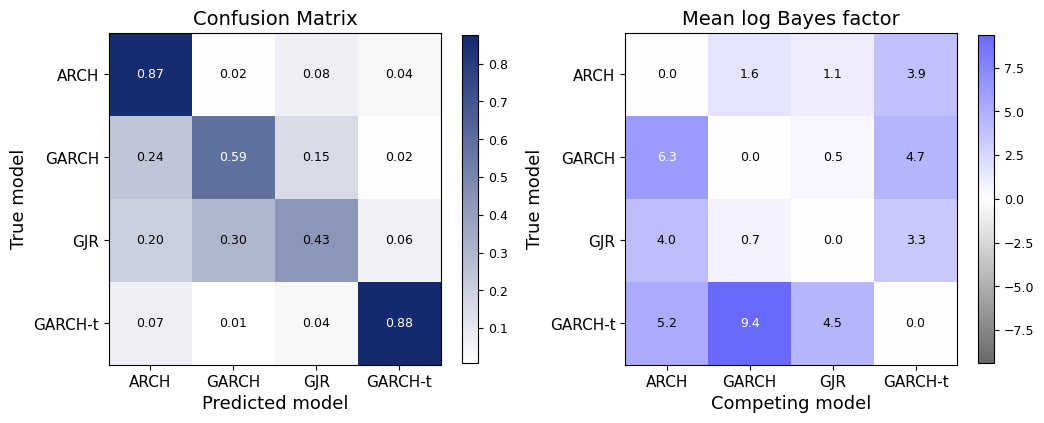

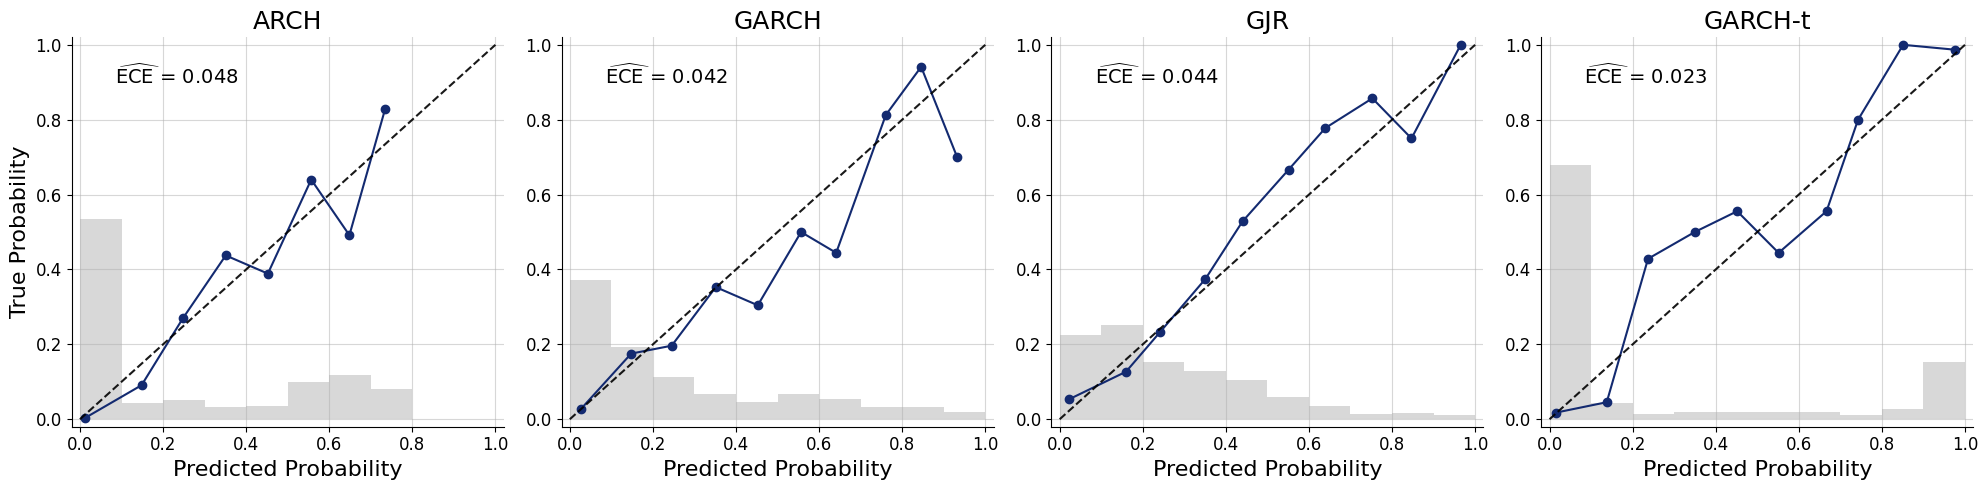

In [45]:
figures = multi_rule_workflow.plot_default_diagnostics(test_data=500)

In [46]:
multi_rule_workflow.compute_default_diagnostics(test_data=val_data)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 6.23 seconds.


,ARCH,GARCH,GJR,GARCH-t
Accuracy,0.921739,0.585821,0.422481,0.823770
Expected Calibration Error,0.030022,0.016770,0.022013,0.023065
Brier Score,0.104729,0.125692,0.147793,0.046388


Congratulations! Through this deep-dive notebook, you have seen all the central aspects of BayesFlow's `ModelComparisonWorkflow`. Now, go ahead and compare your models!